# Aerial Object Classification & Detection 

**Custom CNN Model**

**Step 1: Setup & Suppress Warnings**

In [5]:
import os
import warnings
import logging

# avoid warnings messages
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
warnings.filterwarnings('ignore')
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# check gpu
print("GPU is", "ON ✅" if tf.config.list_physical_devices('GPU') else "OFF ❌")

# (Input Paths)
train_dir = '/kaggle/input/datasets/devahaasan/areial-dataset2/train-20260324T055231Z-1-001'
valid_dir = '/kaggle/input/datasets/devahaasan/areial-dataset2/valid-20260324T055218Z-1-001'
test_dir = '/kaggle/input/datasets/devahaasan/areial-dataset2/test-20260324T055245Z-1-001'

GPU is ON ✅


**Step 2: Understand the Dataset**

In [6]:
import os

# 1. Base directory 

base_dir = '/kaggle/input/datasets/devahaasan/areial-dataset2/train-20260324T055231Z-1-001'


train_dir = os.path.join(base_dir, 'train')


classes = ['bird', 'drone']
if os.path.exists(train_dir):
    for cls in classes:
        path = os.path.join(train_dir, cls)
        if os.path.exists(path):
            print(f"{cls.upper()}: {len(os.listdir(path))} images found ✅")
        else:
            print(f"❌ Error: {cls} folder not found in {train_dir}")
else:
    print(f"❌ Error: Train directory not found at {train_dir}")
    
    print("Checking base directory instead...")
    for cls in classes:
        path = os.path.join(base_dir, cls)
        if os.path.exists(path):
             print(f"{cls.upper()} found in base_dir: {len(os.listdir(path))} images ✅")

BIRD: 1414 images found ✅
DRONE: 1248 images found ✅


**step 3: Data Preprocessing**

In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1.set image and batchsize 
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 2. image 0-255 from 0-1 change (Rescaling)

preprocess_gen = ImageDataGenerator(rescale=1./255)

# 3. Validation and Test  

valid_dir = '/kaggle/input/datasets/devahaasan/areial-dataset2/valid-20260324T055218Z-1-001/valid'

valid_generator = preprocess_gen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print("✅ Step 2: Data Preprocessing (Rescaling & Resizing) initialized.")

Found 442 images belonging to 2 classes.
✅ Step 2: Data Preprocessing (Rescaling & Resizing) initialized.


**Step 4: Data Augmentation**

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Step 3: Data Augmentation for Training Data
# We apply random transformations to help the model generalize better
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalization: Rescale pixel values to [0, 1]
    rotation_range=30,        # Randomly rotate images up to 30 degrees
    width_shift_range=0.2,    # Randomly shift images horizontally
    height_shift_range=0.2,   # Randomly shift images vertically
    shear_range=0.2,          # Apply shear transformations
    zoom_range=0.2,           # Randomly zoom in/out of images
    horizontal_flip=True,     # Randomly flip images horizontally
    fill_mode='nearest'       # Fill in newly created pixels after rotation/shift
)

# Load Training Data from the directory using the augmentation settings
# target_size is set to (224, 224) as per classification requirements
train_generator = train_datagen.flow_from_directory(
    train_dir,                # Path to your Bird and Drone training folders
    target_size=(224, 224),   # Resize images to 224x224
    batch_size=32,            # Process 32 images at a time
    class_mode='binary'       # Use binary mode for Bird vs Drone
)

print("✅ Step 3: Data Augmentation applied and Training Generator ready!")

Found 2662 images belonging to 2 classes.
✅ Step 3: Data Augmentation applied and Training Generator ready!


**Step 5: Model Building (Custom CNN)**

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Step 4: Model Building (Custom CNN)
def build_custom_cnn(input_shape=(224, 224, 3)):
    model = models.Sequential([
        # --- First Convolutional Block ---
        # 32 filters, 3x3 kernel size
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        # Batch Normalization for faster training and stability
        layers.BatchNormalization(),
        # Max Pooling to reduce spatial dimensions (2x2 window)
        layers.MaxPooling2D((2, 2)),
        
        # --- Second Convolutional Block ---
        # 64 filters to capture more complex features
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # --- Third Convolutional Block ---
        # 128 filters for deep feature extraction
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # --- Flattening the 2D maps into a 1D vector ---
        layers.Flatten(),
        
        # --- Dense (Fully Connected) Layers ---
        # 128 units in the hidden layer
        layers.Dense(128, activation='relu'),
        # Dropout to prevent Overfitting (disables 50% of neurons)
        layers.Dropout(0.5), 
        
        # --- Output Layer ---
        # 1 neuron with Sigmoid for Binary Classification (Bird vs Drone)
        layers.Dense(1, activation='sigmoid')
    ])
    
    # Compiling the model with Adam optimizer and Binary Crossentropy loss
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Initialize the Custom CNN Model
custom_cnn_model = build_custom_cnn()

print("--- Step 4: Custom CNN Model Building Completed ---")

# Display the model summary (architecture details)
custom_cnn_model.summary()

--- Step 4: Custom CNN Model Building Completed ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,985 (42.61 MB)

 Trainable params: 11,169,537 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

**Step 6: Model Training(Custom CNN)**

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Step 5: Model Training with Callbacks
# 1. EarlyStopping stops training if the validation loss doesn't improve for 3 epochs
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

# 2. ModelCheckpoint saves the best model version as a .keras file
checkpoint = ModelCheckpoint(
    'best_custom_model.keras', 
    monitor='val_accuracy', 
    save_best_only=True
)

# 3. Fit the model to start training
print("Starting training of Custom CNN model...")
history_custom = custom_cnn_model.fit(
    train_generator,              # Training data with augmentation
    validation_data=valid_generator, # Preprocessed validation data
    epochs=15,                    # Set epochs to 15 (EarlyStopping will manage it)
    callbacks=[early_stop, checkpoint] # Attach callbacks
)

print("\n--- Step 5: Training Completed! ---")

Starting training of Custom CNN model...
Epoch 1/15


I0000 00:00:1774635614.772378     557 service.cc:152] XLA service 0x30e38a30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774635614.772419     557 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774635614.772425     557 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774635615.372763     557 cuda_dnn.cc:529] Loaded cuDNN version 91002


 2/84 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.5469 - loss: 5.3156  

I0000 00:00:1774635622.025154     557 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


84/84 ━━━━━━━━━━━━━━━━━━━━ 58s 575ms/step - accuracy: 0.6379 - loss: 6.7130 - val_accuracy: 0.6742 - val_loss: 7.8069
Epoch 2/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 32s 386ms/step - accuracy: 0.6635 - loss: 1.3887 - val_accuracy: 0.3733 - val_loss: 4.3329
Epoch 3/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 32s 385ms/step - accuracy: 0.7108 - loss: 0.5933 - val_accuracy: 0.5430 - val_loss: 0.8707
Epoch 4/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 33s 388ms/step - accuracy: 0.7126 - loss: 0.6252 - val_accuracy: 0.6335 - val_loss: 1.2750
Epoch 5/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 33s 391ms/step - accuracy: 0.7154 - loss: 0.5687 - val_accuracy: 0.7330 - val_loss: 0.5797
Epoch 6/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 33s 391ms/step - accuracy: 0.7261 - loss: 0.6954 - val_accuracy: 0.6833 - val_loss: 0.5661
Epoch 7/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 446ms/step - accuracy: 0.7294 - loss: 0.6155 - val_accuracy: 0.5339 - val_loss: 0.6645
Epoch 8/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 34s 400ms/step - accuracy: 0.6687 - loss: 0.6958 - val_accuracy: 0.681

Install Keras Tuner

In [1]:
!pip install keras-tuner -q

 **Step 7: Hyperparameter Tuning Code (CNN)**

In [12]:
import keras_tuner as kt
from tensorflow.keras import layers, models, optimizers

# Step 4 (Hyper-tuning): Define a function to build the model with tunable parameters
def build_model(hp):
    model = models.Sequential()
    
    # Tune the number of filters in the first Conv2D layer (Range: 32 to 128)
    model.add(layers.Conv2D(
        filters=hp.Int('conv_1_filter', min_value=32, max_value=128, step=32),
        kernel_size=(3, 3), activation='relu', input_shape=(224, 224, 3)
    ))
    model.add(layers.MaxPooling2D(2, 2))
    
    # Tune the number of Convolutional Layers (Range: 1 to 3)
    for i in range(hp.Int('num_conv_layers', 1, 3)):
        model.add(layers.Conv2D(
            filters=hp.Int(f'conv_{i+2}_filter', min_value=64, max_value=256, step=64),
            kernel_size=(3, 3), activation='relu'
        ))
        model.add(layers.MaxPooling2D(2, 2))
        
    model.add(layers.Flatten())
    
    # Tune the number of units in the Dense layer (Range: 64 to 512)
    model.add(layers.Dense(
        units=hp.Int('dense_units', min_value=64, max_value=512, step=64),
        activation='relu'
    ))
    
    # Tune the Dropout rate (Range: 0.2 to 0.5)
    model.add(layers.Dropout(rate=hp.Float('dropout_rate', 0.2, 0.5, step=0.1)))
    
    model.add(layers.Dense(1, activation='sigmoid'))
    
    # Tune the Learning Rate (Values: 1e-2, 1e-3, 1e-4)
    model.compile(
        optimizer=optimizers.Adam(hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Initialize the RandomSearch Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5, # Number of different combinations to try
    executions_per_trial=1,
    directory='my_tuning_dir',
    project_name='aerial_classification'
)

# Start searching for the best parameters
print("Starting Hyperparameter Tuning...")
tuner.search(train_generator, validation_data=valid_generator, epochs=5)

# Get the best model
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
final_model = tuner.hypermodel.build(best_hps)

print(f"\n--- Best Parameters Found ---")
print(f"Optimal Learning Rate: {best_hps.get('learning_rate')}")
print(f"Optimal Dense Units: {best_hps.get('dense_units')}")

Trial 5 Complete [00h 03m 06s]
val_accuracy: 0.8009049892425537

Best val_accuracy So Far: 0.8009049892425537
Total elapsed time: 00h 17m 04s

--- Best Parameters Found ---
Optimal Learning Rate: 0.0001
Optimal Dense Units: 64


**Step 8: Final Training with Best Parameters(CNN)**

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Get the best model architecture from the tuner
final_model = tuner.hypermodel.build(best_hps)

# 2. Add Callbacks to save the best version and stop early if needed
# EarlyStopping: Stops if validation loss doesn't improve for 5 epochs
# ModelCheckpoint: Saves the model in the new .keras format
my_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_tuned_cnn.keras', monitor='val_accuracy', save_best_only=True)
]

# 3. Final Training for 20 Epochs to reach maximum accuracy
print("Starting final training with optimized parameters...")
history_final = final_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20, 
    callbacks=my_callbacks
)

print("\n--- Final Training Completed! ---")

Starting final training with optimized parameters...
Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 467ms/step - accuracy: 0.5124 - loss: 0.6840 - val_accuracy: 0.6968 - val_loss: 0.5875
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 35s 412ms/step - accuracy: 0.6734 - loss: 0.6093 - val_accuracy: 0.7398 - val_loss: 0.5112
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 34s 407ms/step - accuracy: 0.7434 - loss: 0.5440 - val_accuracy: 0.7557 - val_loss: 0.4986
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 35s 415ms/step - accuracy: 0.7735 - loss: 0.4897 - val_accuracy: 0.7647 - val_loss: 0.4990
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 36s 421ms/step - accuracy: 0.7907 - loss: 0.4525 - val_accuracy: 0.7805 - val_loss: 0.4809
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 34s 406ms/step - accuracy: 0.7747 - loss: 0.4656 - val_accuracy: 0.7534 - val_loss: 0.5547
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 34s 406ms/step - accuracy: 0.7789 - loss: 0.4652 - val_accuracy: 0.7873 - val_loss: 0.4588
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 35s 41

**Step 9: Model Evaluation** 

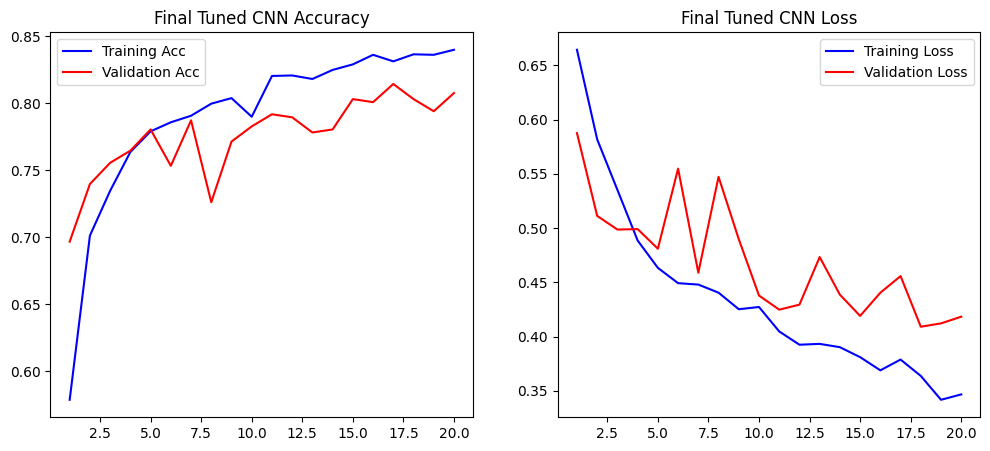

Found 215 images belonging to 2 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 647ms/step


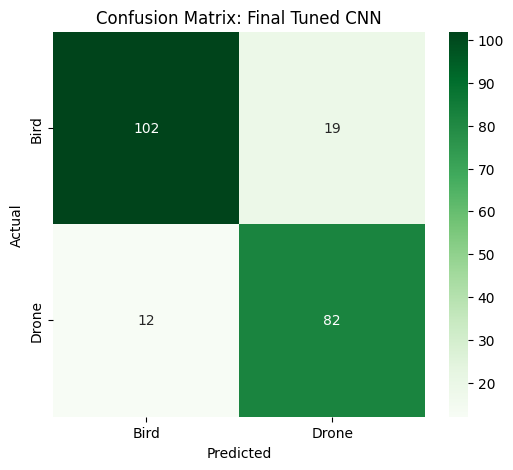


--- Classification Report ---
              precision    recall  f1-score   support

        Bird       0.89      0.84      0.87       121
       Drone       0.81      0.87      0.84        94

    accuracy                           0.86       215
   macro avg       0.85      0.86      0.85       215
weighted avg       0.86      0.86      0.86       215



In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# 1.(Accuracy & Loss Graphs)
def plot_tuning_result(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training Acc')
    plt.plot(epochs, val_acc, 'r', label='Validation Acc')
    plt.title('Final Tuned CNN Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training Loss')
    plt.plot(epochs, val_loss, 'r', label='Validation Loss')
    plt.title('Final Tuned CNN Loss')
    plt.legend()
    plt.show()

plot_tuning_result(history_final)

# 2. (Test Evaluation)
test_dir = '/kaggle/input/datasets/devahaasan/areial-dataset2/test-20260324T055245Z-1-001/test'
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False
)

# (Prediction)
predictions = final_model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int).flatten()
y_true = test_generator.classes

# (Confusion Matrix)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Bird', 'Drone'], yticklabels=['Bird', 'Drone'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Final Tuned CNN')
plt.show()

#  (Classification Report)
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Bird', 'Drone']))

**Step 10: Fine-Tuning (MobileNetV2)**

In [16]:
import os
import warnings
import logging
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers, callbacks

# 1. Suppress warnings and log messages for a clean output
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
warnings.filterwarnings('ignore')
logging.getLogger('tensorflow').setLevel(logging.ERROR)

# 2. Step 4 (Part B): Load Pre-trained MobileNetV2 Base Model
# Load weights trained on ImageNet dataset, excluding the top classification layer
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Initially Freeze the base model to prevent weights from being destroyed during warm-up
base_model.trainable = False

# 3. Add Custom Classification Head for Bird vs Drone
model_ft = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(), # Reduces parameters and prevents overfitting
    layers.BatchNormalization(),      # Improves stability and training speed
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),              # Regularization to handle over-fitting
    layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# 4. Define Callbacks for Step 5 (Model Training)
# EarlyStopping stops training if val_loss doesn't improve for 3 epochs
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
# ModelCheckpoint saves the best model version based on val_accuracy
checkpoint = callbacks.ModelCheckpoint('aerial_finetuned_best.keras', monitor='val_accuracy', save_best_only=True)

# 5. PHASE 1: Training the custom head (Warm-up)
# Use a standard learning rate (0.001) for the new layers
model_ft.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

print("--- Phase 1: Training top layers (Warm-up) ---")
model_ft.fit(train_generator, 
             validation_data=valid_generator, 
             epochs=5, 
             callbacks=[early_stop, checkpoint])

# 6. PHASE 2: Fine-Tuning the entire model
# Unfreeze the base model layers to allow the model to learn aerial features
base_model.trainable = True

# Re-compile with a VERY LOW learning rate (0.00001) to fine-tune pre-trained weights
model_ft.compile(optimizer=optimizers.Adam(learning_rate=0.00001), 
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

print("\n--- Phase 2: Starting Fine-Tuning for Maximum Accuracy ---")
history_ft = model_ft.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10, 
    callbacks=[early_stop, checkpoint]
)

print("\n✅ Fine-Tuning Completed! Your best model is saved.")

--- Phase 1: Training top layers (Warm-up) ---
Epoch 1/5


2026-03-27 19:47:59.405292: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 19:47:59.543884: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


22/84 ━━━━━━━━━━━━━━━━━━━━ 26s 431ms/step - accuracy: 0.7520 - loss: 0.4962

2026-03-27 19:48:20.864039: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 19:48:21.002361: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 19:48:21.139123: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 572ms/step - accuracy: 0.8556 - loss: 0.3315

2026-03-27 19:49:05.297834: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 19:49:05.435430: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


84/84 ━━━━━━━━━━━━━━━━━━━━ 85s 791ms/step - accuracy: 0.8563 - loss: 0.3301 - val_accuracy: 0.9638 - val_loss: 0.0844
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 35s 417ms/step - accuracy: 0.9728 - loss: 0.0750 - val_accuracy: 0.9706 - val_loss: 0.0812
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 34s 404ms/step - accuracy: 0.9768 - loss: 0.0673 - val_accuracy: 0.9683 - val_loss: 0.0808
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 36s 423ms/step - accuracy: 0.9839 - loss: 0.0472 - val_accuracy: 0.9819 - val_loss: 0.0755
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 35s 414ms/step - accuracy: 0.9793 - loss: 0.0455 - val_accuracy: 0.9751 - val_loss: 0.0805

--- Phase 2: Starting Fine-Tuning for Maximum Accuracy ---
Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 122s 831ms/step - accuracy: 0.9362 - loss: 0.1826 - val_accuracy: 0.9706 - val_loss: 0.0728
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 36s 425ms/step - accuracy: 0.9543 - loss: 0.1061 - val_accuracy: 0.9661 - val_loss: 0.0764
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 36s 429ms/ste

**Step 11: Evaluation & Comparison**

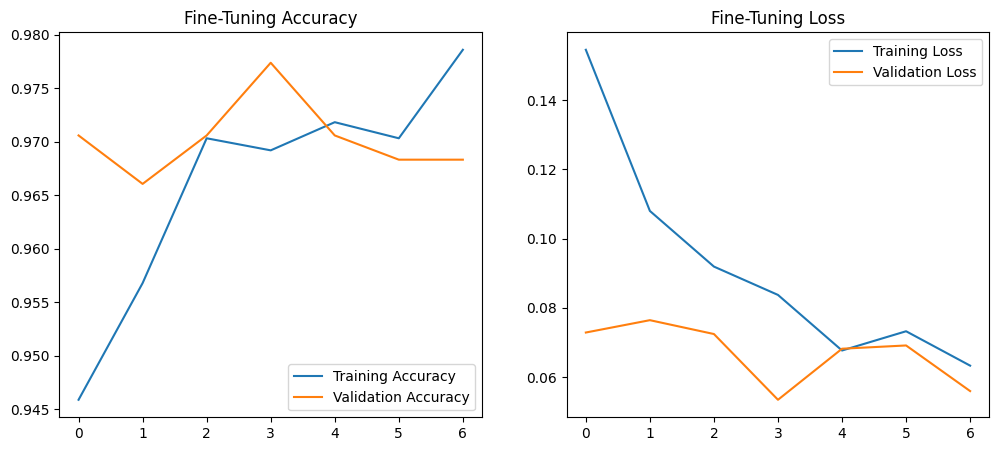


Evaluating on Test Dataset...
6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step

2026-03-27 20:00:47.464309: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 20:00:47.602511: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step 

--- Classification Report ---
              precision    recall  f1-score   support

        Bird       0.98      1.00      0.99       121
       Drone       1.00      0.98      0.99        94

    accuracy                           0.99       215
   macro avg       0.99      0.99      0.99       215
weighted avg       0.99      0.99      0.99       215



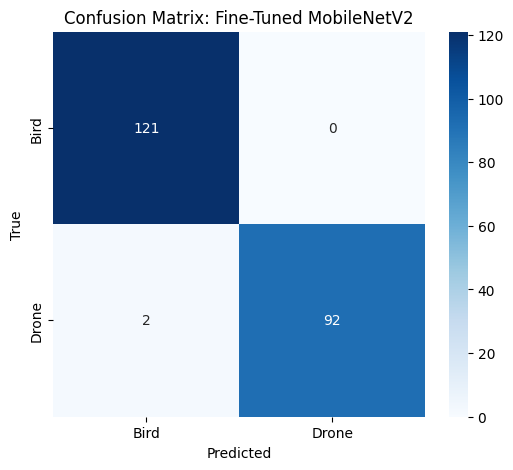

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# --- 1. Plot Training History (Step 6) ---
# Visualizing how the accuracy and loss improved during Fine-Tuning
def plot_finetune_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Fine-Tuning Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title('Fine-Tuning Loss')
    plt.legend()
    plt.show()

plot_finetune_history(history_ft)

# --- 2. Confusion Matrix & Detailed Report (Step 6) ---
# Evaluating on the unseen Test Data
print("\nEvaluating on Test Dataset...")
test_predictions = model_ft.predict(test_generator)
y_pred = (test_predictions > 0.5).astype(int).flatten()
y_true = test_generator.classes

# Display Classification Report (Precision, Recall, F1-Score)
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Bird', 'Drone']))

# Display Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Bird', 'Drone'], yticklabels=['Bird', 'Drone'])
plt.title('Confusion Matrix: Fine-Tuned MobileNetV2')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

**Step 12: Model Save**

In [19]:
model_ft.save('aerial_finetuned_final.keras')

print("✅ Final Fine-Tuned Model Saved Successfully!")

✅ Final Fine-Tuned Model Saved Successfully!
